<a href="https://colab.research.google.com/github/DJCordhose/buch-machine-learning-notebooks/blob/master/pytorch/kap8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visuelle Regressionstests mit Autoencodern (PyTorch)

Diese Version nutzt PyTorch idiomatisch: `nn.Module`, `DataLoader`, explizite Trainings- und Evaluationsschleifen sowie Tensoren im Channel-first-Format `(N, C, H, W)`. Die Auswertungen und Grafiken bleiben so nah wie möglich am Keras-Original.

In [25]:
import sys
if 'google.colab' in sys.modules:
    !pip install -q torchinfo
    !pip install -q torchmetrics
    !pip install -q torchview

In [1]:
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (20, 8)
# mpl.rcParams["figure.dpi"] = 300
mpl.rcParams['axes.titlesize'] = 24
mpl.rcParams['axes.labelsize'] = 20

In [2]:
import numpy as np
np.random.seed(42)

In [3]:
import torch
torch.__version__

'2.11.0+cu128'

In [4]:
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

In [5]:
# Beschleuniger ermitteln
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(device.type)

cuda


In [6]:
# In der Keras-Version wurde hier lrcurve installiert.
# In PyTorch protokollieren wir Loss und Accuracy explizit in der Trainingsschleife.

In [7]:
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

# Schritt 1: Laden und Aufbereitung der Daten

In [8]:
%env AUTOENC_DIR=./datasets/Autoencoder
!mkdir -p $AUTOENC_DIR/
!curl -o $AUTOENC_DIR/golden-master.zip \
    https://raw.githubusercontent.com/DJCordhose/buch-machine-learning-notebooks/master/data/app-testing/golden-master.zip

env: AUTOENC_DIR=./datasets/Autoencoder
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 7589k  100 7589k    0     0  11.0M      0 --:--:-- --:--:-- --:--:-- 10.9M


In [9]:
!unzip -jqo $AUTOENC_DIR/golden-master.zip -d $AUTOENC_DIR/train

In [10]:
!ls $AUTOENC_DIR/train

100.png  16.png   238.png  306.png  375.png  443.png  5.png	  big-39.png
101.png  170.png  239.png  307.png  376.png  444.png  60.png	  big-3.png
102.png  171.png  23.png   308.png  377.png  445.png  61.png	  big-40.png
103.png  172.png  240.png  309.png  378.png  446.png  62.png	  big-41.png
104.png  173.png  241.png  30.png   379.png  447.png  63.png	  big-42.png
105.png  174.png  242.png  310.png  37.png   448.png  64.png	  big-43.png
106.png  175.png  243.png  311.png  380.png  449.png  65.png	  big-44.png
107.png  176.png  244.png  312.png  381.png  44.png   66.png	  big-45.png
108.png  177.png  245.png  313.png  382.png  450.png  67.png	  big-46.png
109.png  178.png  246.png  314.png  383.png  451.png  68.png	  big-47.png
10.png	 179.png  247.png  315.png  384.png  452.png  69.png	  big-48.png
110.png  17.png   248.png  316.png  385.png  453.png  6.png	  big-49.png
111.png  180.png  249.png  317.png  386.png  454.png  70.png	  big-4.png
112.png  181.png  24.png   318.png  387.png

In [11]:
!curl -o $AUTOENC_DIR/regression.zip \
     https://raw.githubusercontent.com/DJCordhose/buch-machine-learning-notebooks/master/data/app-testing/regression.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  830k  100  830k    0     0  1149k      0 --:--:-- --:--:-- --:--:-- 1148k


In [12]:
!unzip -jqo $AUTOENC_DIR/regression.zip -d $AUTOENC_DIR/test

In [13]:
# !ls -l $AUTOENC_DIR/test

In [14]:
# Für eine symmetrische Form des Autoencoders ist eine Zweierpotenz für die Auflösung am einfachsten
x_res, y_res = (256, 256)

In [15]:
# Kleine Hilfsfunktion zum Einlesen der Bilder
import os
import numpy as np
from skimage           import data, io, filters
from skimage.transform import rescale, resize, downscale_local_mean
from skimage.color     import rgb2gray

def read_images_from_dir(data_dir, dims=(356, 384), type = ".png"):
  x_dim, y_dim = dims
  images = []
  file_names = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(type)]
  for f in file_names:
    image = io.imread(f)
    # some images from regressed application often have an additional line break
    # we take the easy route and simply clip to have the same size for all images
    image = image[:x_dim, :y_dim]
    image = image[:,:,:3] # might have 4 color channels, but rgb2gray expects 3
    image = rgb2gray(image)
    image = resize(image, (x_res, y_res))
    images.append(image)

  images = np.array(images)


  return images

In [16]:
autoenc_dir = './datasets/Autoencoder/'

train = read_images_from_dir(autoenc_dir + "train")
train.shape, train.dtype

((603, 256, 256), dtype('float64'))

In [17]:
test = read_images_from_dir(autoenc_dir + "test")
test.shape, test.dtype

((51, 256, 256), dtype('float64'))

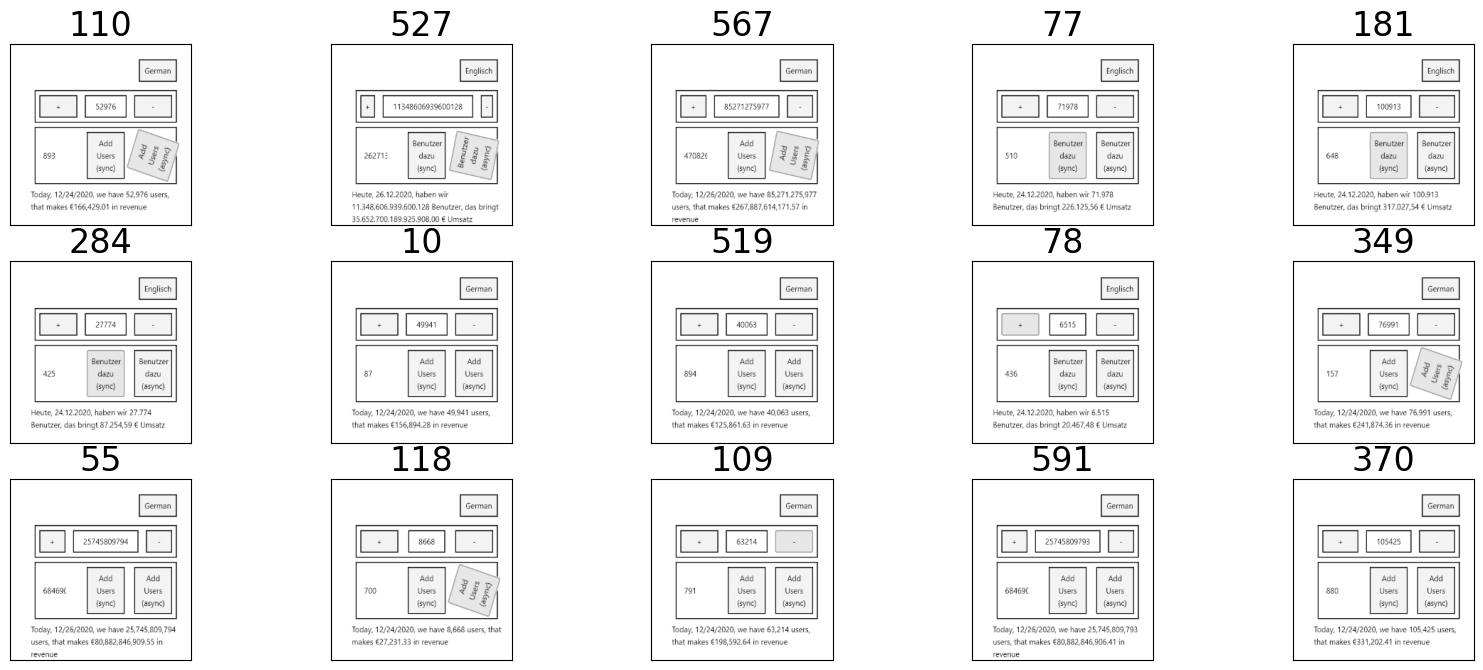

In [18]:
import matplotlib.pyplot as plt

def plot_samples(x, n_samples=15):
  figure = plt.figure()
  for i, index in enumerate(np.random.choice(x.shape[0], size=n_samples, replace=False)):
      ax = figure.add_subplot(3, 5, i + 1, xticks=[], yticks=[])
      ax.imshow(x[index], cmap="gray")
      ax.set_title("{}".format(index))

plot_samples(train)

# Schritt 2: Training des Autoencoders

* Der Encoder nutzt gewöhnliche Convolutional Layers.
* Der Decoder nutzt transponierte Faltungen und Upsampling.
* Der Flaschenhals nutzt lediglich 8 Neuronen; weniger als 8 wird wahrscheinlich nicht stabil trainieren.
* Wir nutzen eine spezielle Accuracy, die zählt, wie viele Pixel stimmen, wenn man das Problem auf Schwarz/Weiß reduziert.

In [19]:
def rounded_accuracy(y_true, y_pred):
    return (torch.round(y_true) == torch.round(y_pred)).float().mean()

In [20]:
# Dimension des Flaschenhalses
# geringer als 8 gibt es wenige Erfolgsaussichten
encoding_dim = 8

In [21]:
kernel_size = 4 # Filtergröße
stride      = 2 # Schrittweite

# Migrationshinweis (TF -> PT):
# In PT gibt es keine separate Input-Schicht.
# TF-Reshape findet bei Erstellung der Tensoren per unsqueeze() stat.
class Encoder(nn.Module):
    def __init__(self, encoding_dim):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=kernel_size, stride=stride, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(64, 32, kernel_size=kernel_size, stride=stride, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(32, 16, kernel_size=kernel_size, stride=stride, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 1, kernel_size=kernel_size, stride=1, padding="same"),
            nn.Flatten(),
        )
        self.latent = nn.Linear(8 * 8, encoding_dim)

    def forward(self, x):
        x = self.features(x)
        return self.latent(x)

class Decoder(nn.Module):
    def __init__(self, encoding_dim):
        super().__init__()

        self.layers = nn.Sequential(
            nn.Linear(encoding_dim, encoding_dim),
            nn.Unflatten(1, (encoding_dim, 1, 1)),

            nn.ConvTranspose2d(encoding_dim, 8, kernel_size=kernel_size, stride=stride, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="nearest"),

            nn.ConvTranspose2d(8, 16, kernel_size=kernel_size, stride=stride, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="nearest"),

            nn.ConvTranspose2d(16, 32, kernel_size=kernel_size, stride=stride, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="nearest"),

            nn.ConvTranspose2d(32, 64, kernel_size=kernel_size, stride=stride, padding=1),
            nn.ReLU(),
            nn.Upsample(scale_factor=2, mode="nearest"),

            nn.Conv2d(64, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.layers(x)

class Autoencoder(nn.Module):
    def __init__(self, encoding_dim):
        super().__init__()
        self.encoder = Encoder(encoding_dim)
        self.decoder = Decoder(encoding_dim)

    def forward(self, x):
        x = self.encoder(x)
        return self.decoder(x)


encoder     = Encoder(encoding_dim).to(device)
decoder     = Decoder(encoding_dim).to(device)
autoencoder = Autoencoder(encoding_dim).to(device)

## Informationen über das Modell und weitere Details ausgeben:

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
Encoder                                  [1, 1, 256, 256]          [1, 8]                    --
├─Sequential: 1-1                        [1, 1, 256, 256]          [1, 64]                   --
│    └─Conv2d: 2-1                       [1, 1, 256, 256]          [1, 64, 128, 128]         1,088
│    └─ReLU: 2-2                         [1, 64, 128, 128]         [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-3                    [1, 64, 128, 128]         [1, 64, 64, 64]           --
│    └─Conv2d: 2-4                       [1, 64, 64, 64]           [1, 32, 32, 32]           32,800
│    └─ReLU: 2-5                         [1, 32, 32, 32]           [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-6                    [1, 32, 32, 32]           [1, 32, 16, 16]           --
│    └─Conv2d: 2-7                       [1, 32, 16, 16]           [1, 16, 8, 8]             8,208
│    └─ReLU: 2-8         

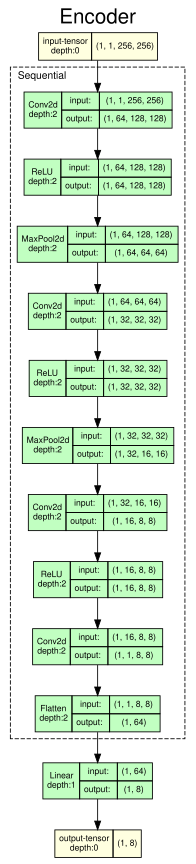

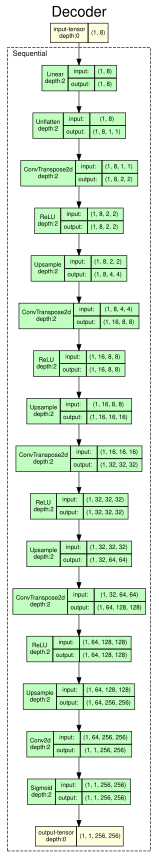

In [26]:
from torchinfo import summary

encoder = encoder.to(device)
decoder = decoder.to(device)

# Modellbeschreibung f. Encoder und Decoder ausgeben
print(
    summary(
        encoder,
        input_size=(1, 1, x_res, y_res),
        device=device,
        col_names=("input_size", "output_size", "num_params"),
    ),
)

print()

print(
    summary(
        decoder,
        input_size=(1, encoding_dim),
        device=device,
        col_names=("input_size", "output_size", "num_params"),
    )
)

# Optional, falls eine graphische Darstellung wie bei Keras plot_model gewünscht ist:
# !pip install -q torchview graphviz
from torchview import draw_graph

encoder_graph = draw_graph(
    encoder,
    input_size=(1, 1, x_res, y_res),
    expand_nested=True
)

encoder_graph.visual_graph.graph_attr["label"] = "Encoder"
encoder_graph.visual_graph.graph_attr["labelloc"] = "t"
encoder_graph.visual_graph.graph_attr["fontsize"] = "24"
encoder_graph.visual_graph.graph_attr["fontname"] = "Helvetica"
encoder_graph.visual_graph.node_attr["fontname"] = "Helvetica"
encoder_graph.visual_graph.edge_attr["fontname"] = "Helvetica"

display( encoder_graph.visual_graph )

decoder_graph = draw_graph(
    decoder,
    input_size=(1, encoding_dim),
    expand_nested=True
)

decoder_graph.visual_graph.graph_attr["label"] = "Decoder"
decoder_graph.visual_graph.graph_attr["labelloc"] = "t"
decoder_graph.visual_graph.graph_attr["fontsize"] = "24"
decoder_graph.visual_graph.graph_attr["fontname"] = "Helvetica"
decoder_graph.visual_graph.node_attr["fontname"] = "Helvetica"
decoder_graph.visual_graph.edge_attr["fontname"] = "Helvetica"

display( decoder_graph.visual_graph )

In [27]:
%%time

loss_fn   = nn.BCELoss()
optimizer = torch.optim.Adam(autoencoder.parameters())

BATCH_SIZE = 4     # can be higher when dimension of hidden representation is higher
EPOCHS     = 100   # typically this is more than enough

# PyTorch erwartet Bilddaten für Conv2d in der Form:
# (Batch, Kanäle, Höhe, Breite).
# Unsere Bilder liegen bislang nur als Graustufenbilder
# der Form (Batch, Höhe, Breite) vor.
# unsqueeze(1) fügt deshalb die zusätzliche Kanal-Dimension ein.
train_tensor = torch.from_numpy(train).float().unsqueeze(1)
test_tensor  = torch.from_numpy( test).float().unsqueeze(1)


# DataLoader definierren:
train_loader = DataLoader(
    TensorDataset(train_tensor, train_tensor),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    TensorDataset(test_tensor, test_tensor),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

history = {
    "loss":                 [],
    "val_loss":             [],
    "rounded_accuracy":     [],
    "val_rounded_accuracy": [],
}

def evaluate_model(model, loader):
    model.eval()
    total_loss = 0.0
    total_acc  = 0.0
    total      = 0

    with torch.no_grad():
        for data, target in loader:
            data   = data.to(device)
            target = target.to(device)
            pred   = model(data)
            loss   = loss_fn(pred, target)

            batch_size = data.size(0)
            total_loss += loss.item() * batch_size
            total_acc += rounded_accuracy(target, pred).item() * batch_size
            total += batch_size

    return total_loss / total, total_acc / total

for epoch in range(EPOCHS):
    autoencoder.train()
    total_loss = 0.0
    total_acc = 0.0
    total = 0

    for data, target in train_loader:
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        pred = autoencoder(data)
        loss = loss_fn(pred, target)
        loss.backward()
        optimizer.step()

        batch_size = data.size(0)
        total_loss += loss.item() * batch_size
        total_acc += rounded_accuracy(target, pred).item() * batch_size
        total += batch_size

    train_loss = total_loss / total
    train_acc = total_acc / total
    val_loss, val_acc = evaluate_model(autoencoder, test_loader)

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["rounded_accuracy"].append(train_acc)
    history["val_rounded_accuracy"].append(val_acc)

    print(
        f"Epoche {epoch + 1:03d}/{EPOCHS} | "
        f"loss: {train_loss:.4f} | rounded_accuracy: {train_acc:.4f} | "
        f"val_loss: {val_loss:.4f} | val_rounded_accuracy: {val_acc:.4f}"
    )

Epoche 001/100 | loss: 0.2690 | rounded_accuracy: 0.9262 | val_loss: 0.2057 | val_rounded_accuracy: 0.9407
Epoche 002/100 | loss: 0.1342 | rounded_accuracy: 0.9667 | val_loss: 0.1462 | val_rounded_accuracy: 0.9681
Epoche 003/100 | loss: 0.1168 | rounded_accuracy: 0.9763 | val_loss: 0.1457 | val_rounded_accuracy: 0.9718
Epoche 004/100 | loss: 0.1141 | rounded_accuracy: 0.9781 | val_loss: 0.1346 | val_rounded_accuracy: 0.9699
Epoche 005/100 | loss: 0.1130 | rounded_accuracy: 0.9785 | val_loss: 0.1369 | val_rounded_accuracy: 0.9711
Epoche 006/100 | loss: 0.1122 | rounded_accuracy: 0.9788 | val_loss: 0.1381 | val_rounded_accuracy: 0.9722
Epoche 007/100 | loss: 0.1114 | rounded_accuracy: 0.9793 | val_loss: 0.1375 | val_rounded_accuracy: 0.9724
Epoche 008/100 | loss: 0.1109 | rounded_accuracy: 0.9796 | val_loss: 0.1411 | val_rounded_accuracy: 0.9718
Epoche 009/100 | loss: 0.1108 | rounded_accuracy: 0.9793 | val_loss: 0.1423 | val_rounded_accuracy: 0.9726
Epoche 010/100 | loss: 0.1103 | round

In [28]:
train_loss, train_accuracy = evaluate_model(autoencoder, train_loader)
train_accuracy

0.9896699265263369

In [29]:
test_loss, test_accuracy = evaluate_model(autoencoder, test_loader)
test_accuracy

0.9765206142967823

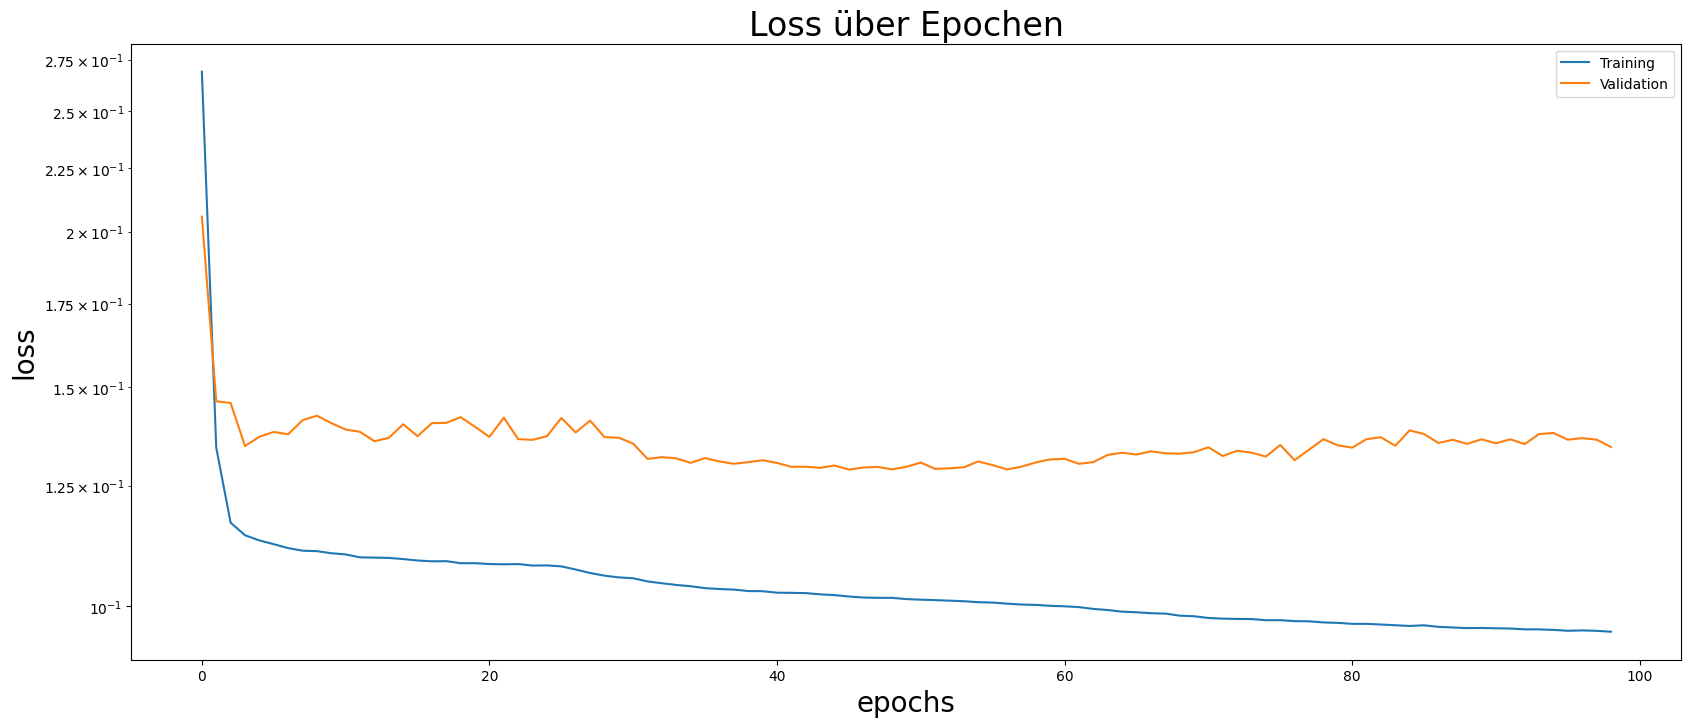

In [30]:
START_EPOCHE = 0
END_EPOCHE   = -1

plt.yscale('log')
plt.ylabel("loss")
plt.xlabel("epochs")
plt.title('Loss über Epochen')

plt.plot(history['loss'][START_EPOCHE:END_EPOCHE]);
plt.plot(history['val_loss'][START_EPOCHE:END_EPOCHE]);

plt.legend(['Training', 'Validation']);

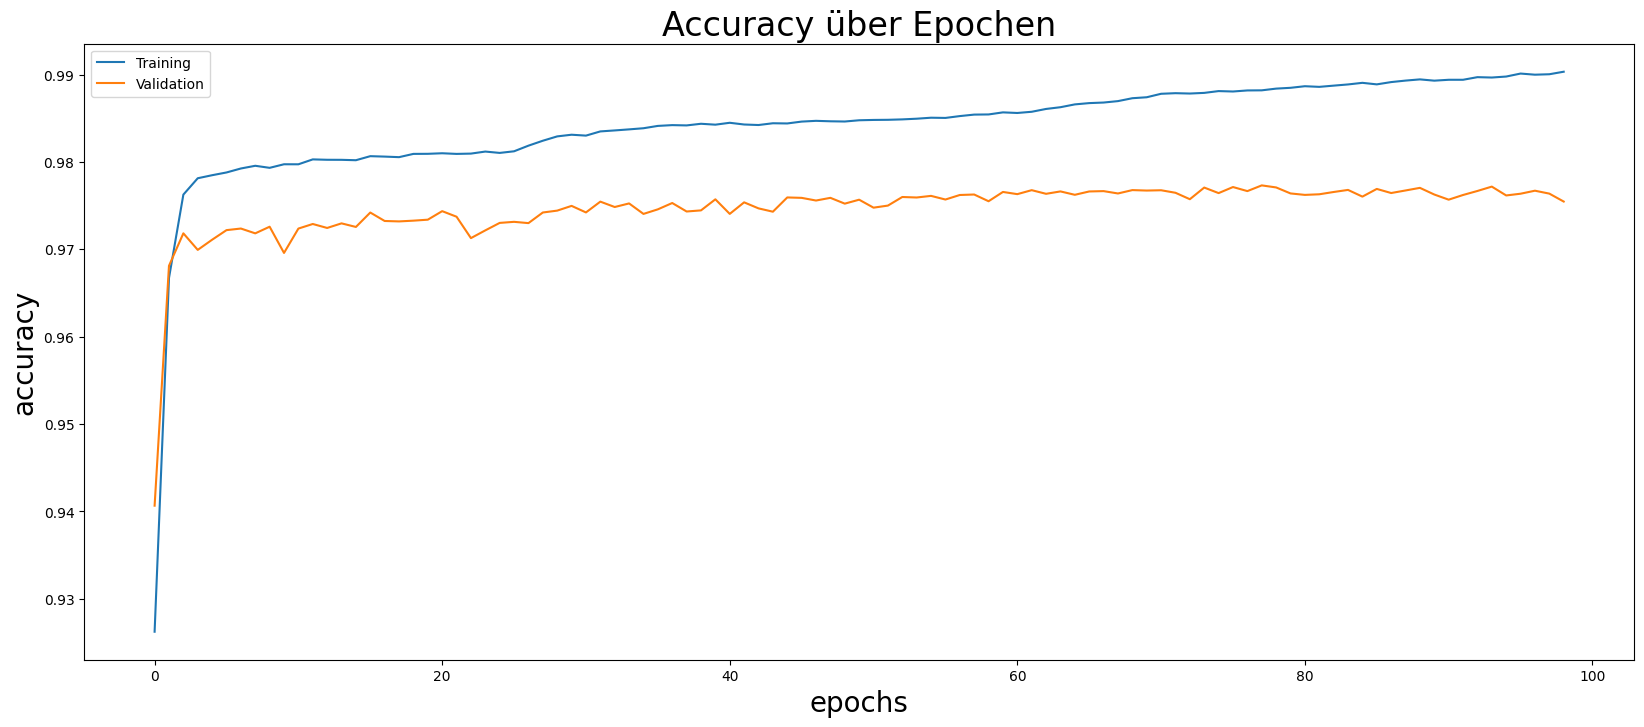

In [31]:
plt.ylabel("accuracy")
plt.xlabel("epochs")
plt.title('Accuracy über Epochen')

plt.plot(history['rounded_accuracy'][START_EPOCHE:END_EPOCHE])
plt.plot(history['val_rounded_accuracy'][START_EPOCHE:END_EPOCHE])

plt.legend(['Training', 'Validation']);

# Schritt 3: Ergebnisse überprüfen

In [32]:
def predict_images(model, images, batch_size=BATCH_SIZE):
    tensor = torch.from_numpy(images).float().unsqueeze(1)
    loader = DataLoader(tensor, batch_size=batch_size, shuffle=False)
    predictions = []

    model.eval()
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            pred = model(data).cpu().squeeze(1).numpy()
            predictions.append(pred)

    return np.concatenate(predictions, axis=0)

train_pred = predict_images(autoencoder, train)

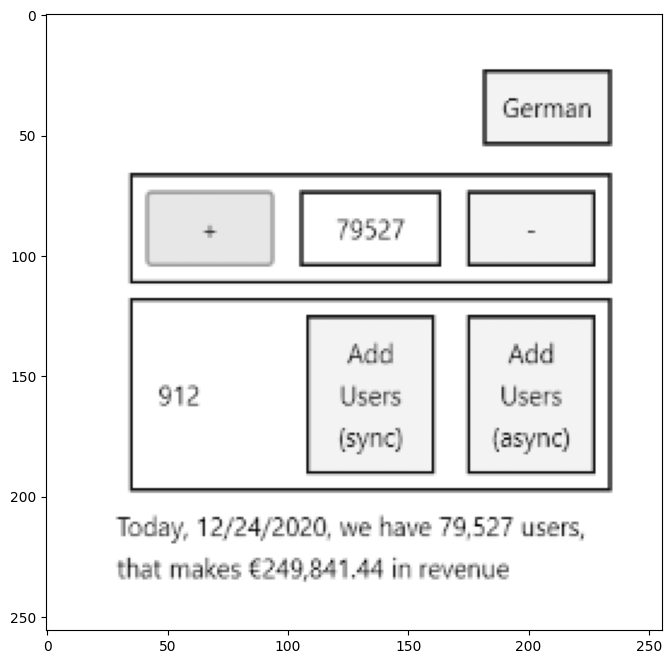

In [33]:
index = 50
plt.imshow(train[index], cmap='gray')
# io.imsave('train_true.png', train[index])

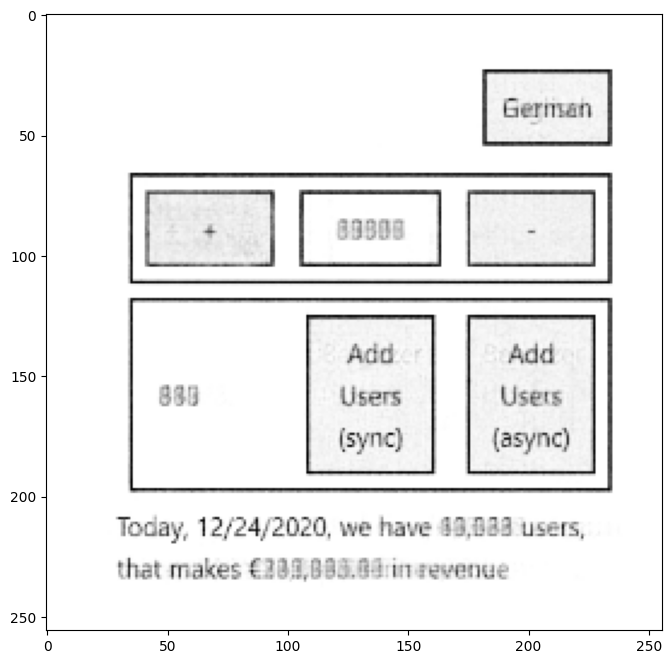

In [34]:
plt.imshow(train_pred[index], cmap='gray')
# io.imsave('train_pred.png', train_pred[index])

In [35]:
# Wie groß ist die Ähnlichkeit zwischen Rekonstruktion und Originalbild?
rounded_accuracy(
    torch.as_tensor(train[50]).float(),
    torch.as_tensor(train_pred[50]).float()
).item()

0.9909210205078125

In [36]:
test_pred = predict_images(autoencoder, test)

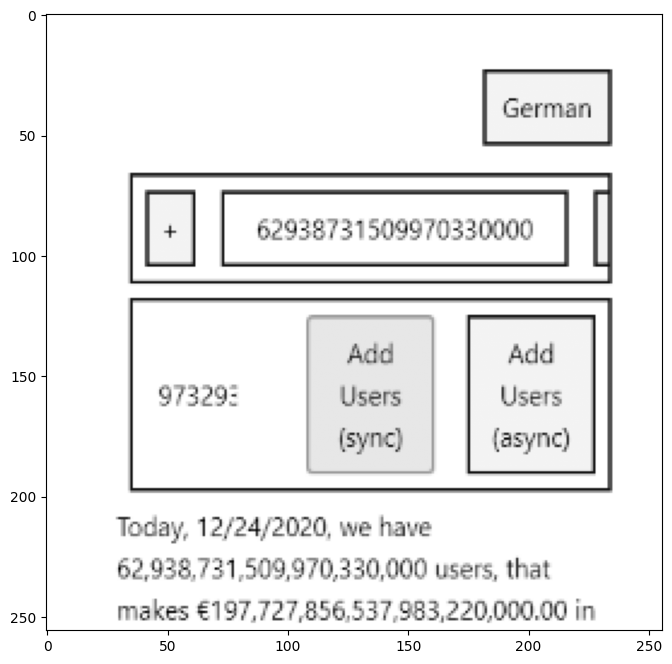

In [37]:
index = 21
# index = 24
plt.imshow(test[index], cmap='gray')
# io.imsave('test_true.png', test[index])

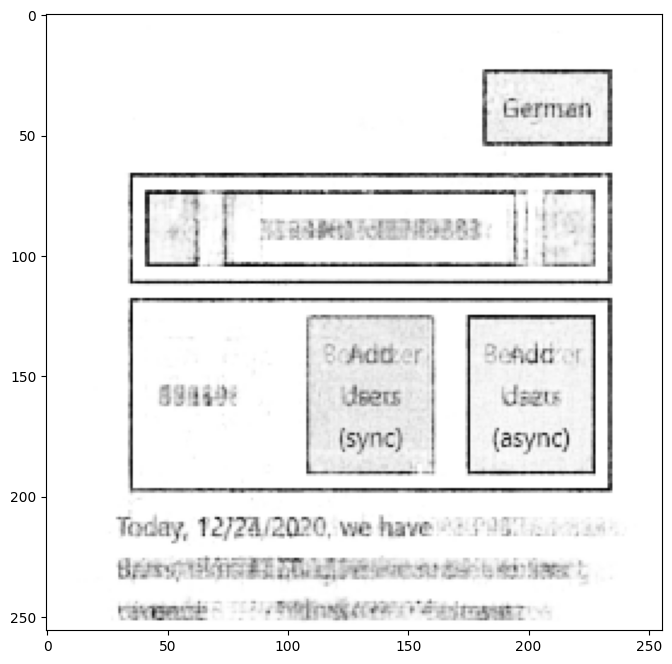

In [38]:
plt.imshow(test_pred[index], cmap='gray')
# io.imsave('test_pred.png', test_pred[index])

In [39]:
rounded_accuracy(
    torch.as_tensor(test[0]).float(),
    torch.as_tensor(test_pred[0]).float()
).item()

0.9732208251953125

## Training Set

In [40]:
def compare_samples(x, x_pred, n_samples=5):
  n_samples = min(n_samples, len(x))
  figure = plt.figure()
  for i, index in enumerate(np.random.choice(x.shape[0], size=n_samples, replace=False)):
      acc = rounded_accuracy(
        torch.as_tensor(x[index]).float(),
        torch.as_tensor(x_pred[index]).float()
      ).item()
      ax = figure.add_subplot(2, n_samples, i + 1, xticks=[], yticks=[])
      ax.set_title("{}".format(index))
      ax.imshow(x[index], cmap="gray")
      ax = figure.add_subplot(2, n_samples, i + 1 + n_samples, xticks=[], yticks=[])
      ax.set_title("{:.4f}".format(acc))
      ax.imshow(x_pred[index], cmap="gray")

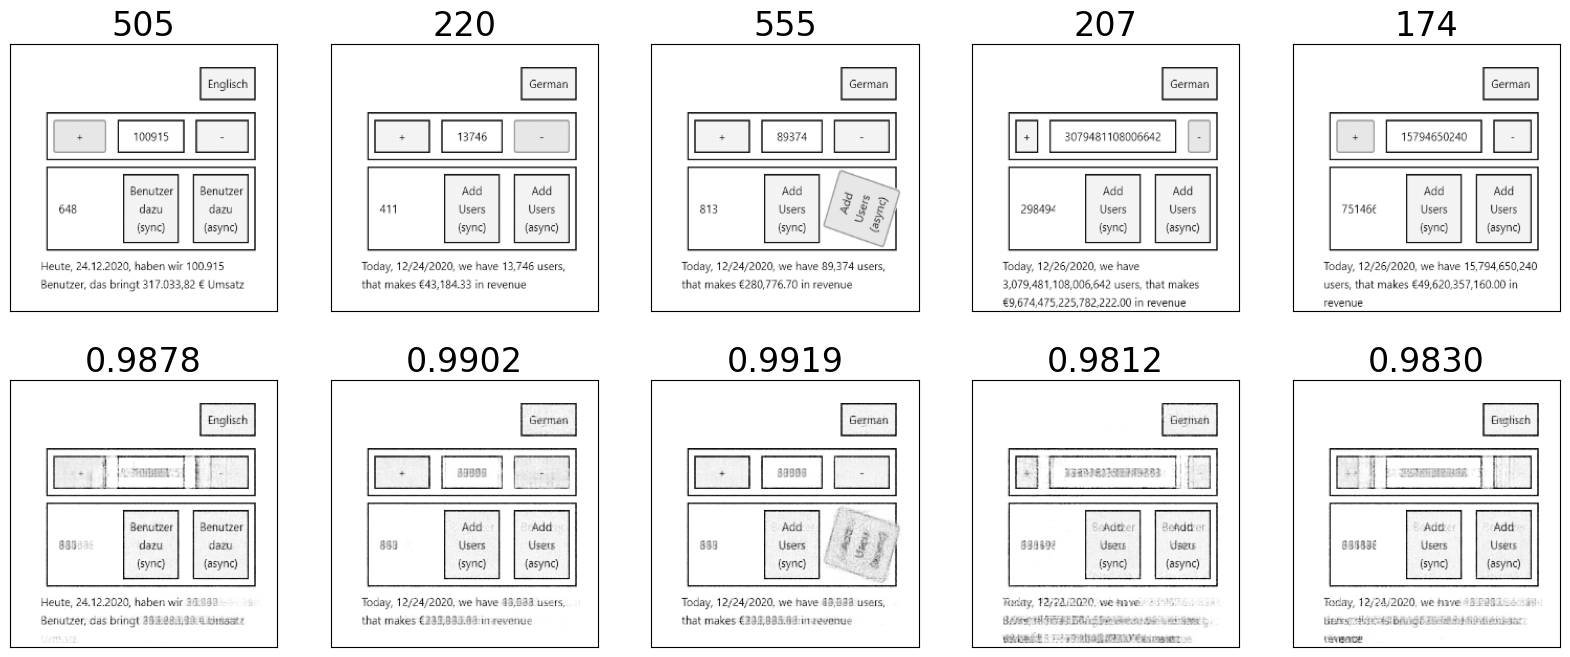

In [41]:
compare_samples(train, train_pred)

In [42]:
scores = []
for true_image, predicted_image in zip(train, train_pred):
  score = rounded_accuracy(
    torch.as_tensor(true_image).float(),
    torch.as_tensor(predicted_image).float()
  ).item()
  scores.append(score)

train_scores = np.array(scores)
train_scores.shape

(603,)

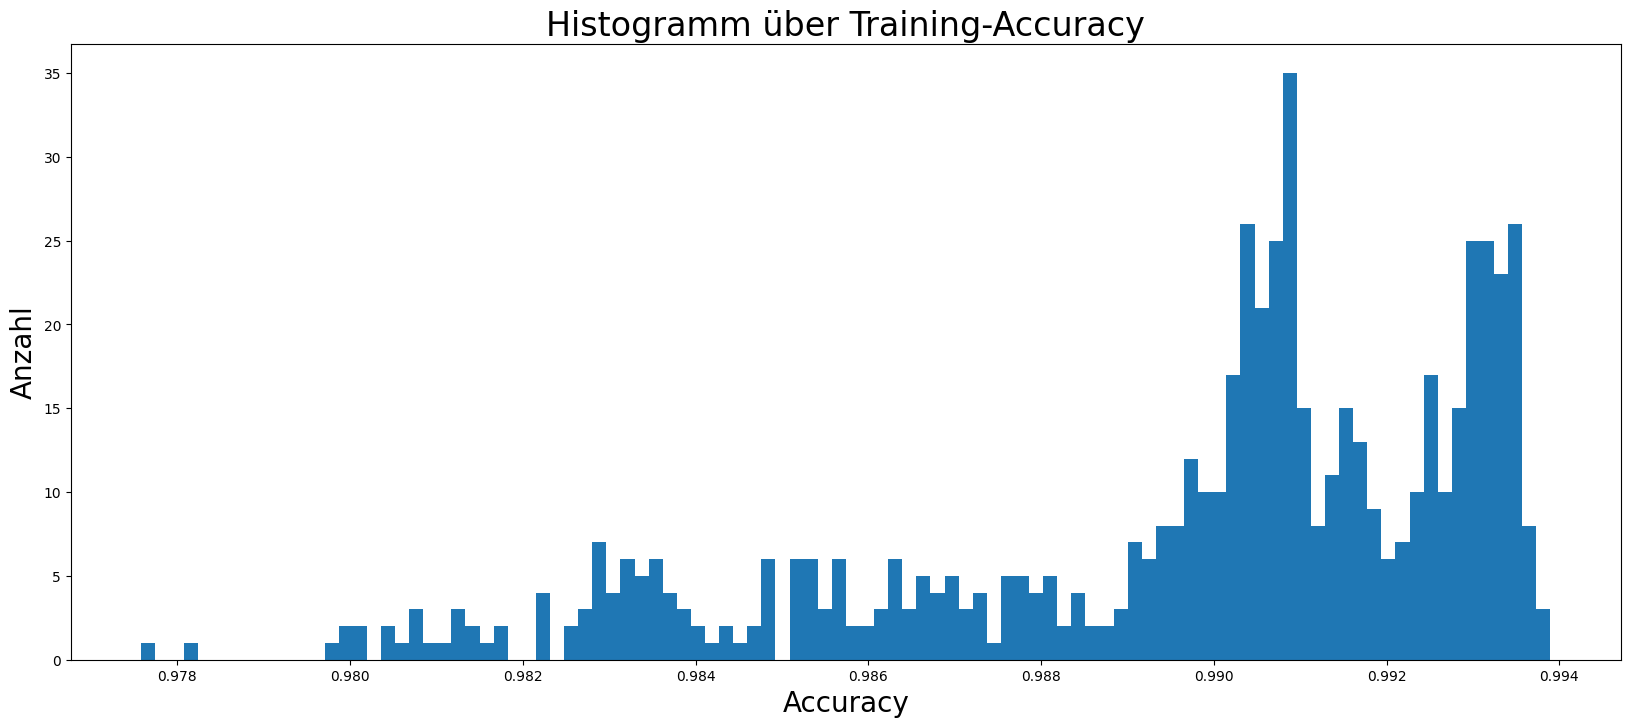

In [43]:
plt.title('Histogramm über Training-Accuracy')
plt.ylabel("Anzahl")
plt.xlabel("Accuracy")

plt.hist(train_scores, bins=100);

## Test Set

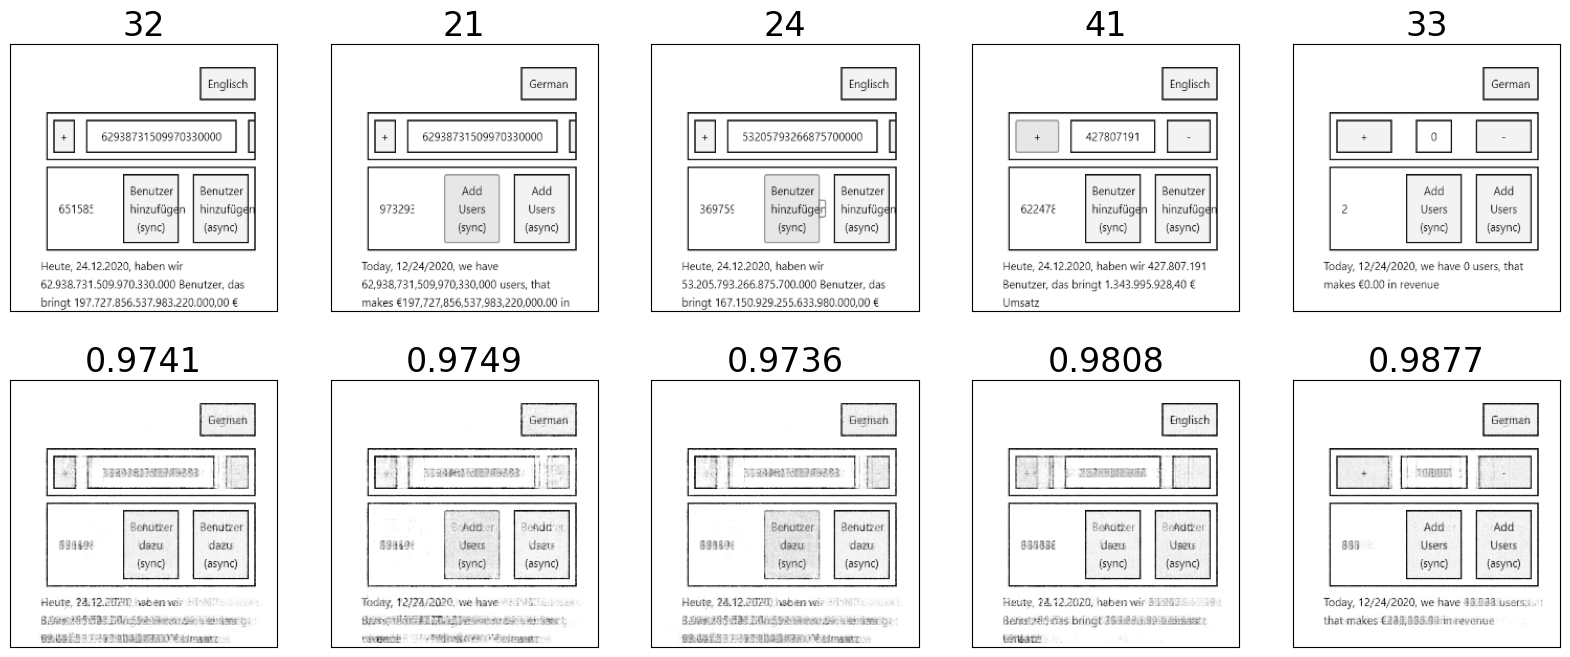

In [44]:
compare_samples(test, test_pred)

In [45]:
scores = []
for true_image, predicted_image in zip(test, test_pred):
  score = rounded_accuracy(
    torch.as_tensor(true_image).float(),
    torch.as_tensor(predicted_image).float()
  ).item()
  scores.append(score)
test_scores = np.array(scores)
test_scores.shape

(51,)

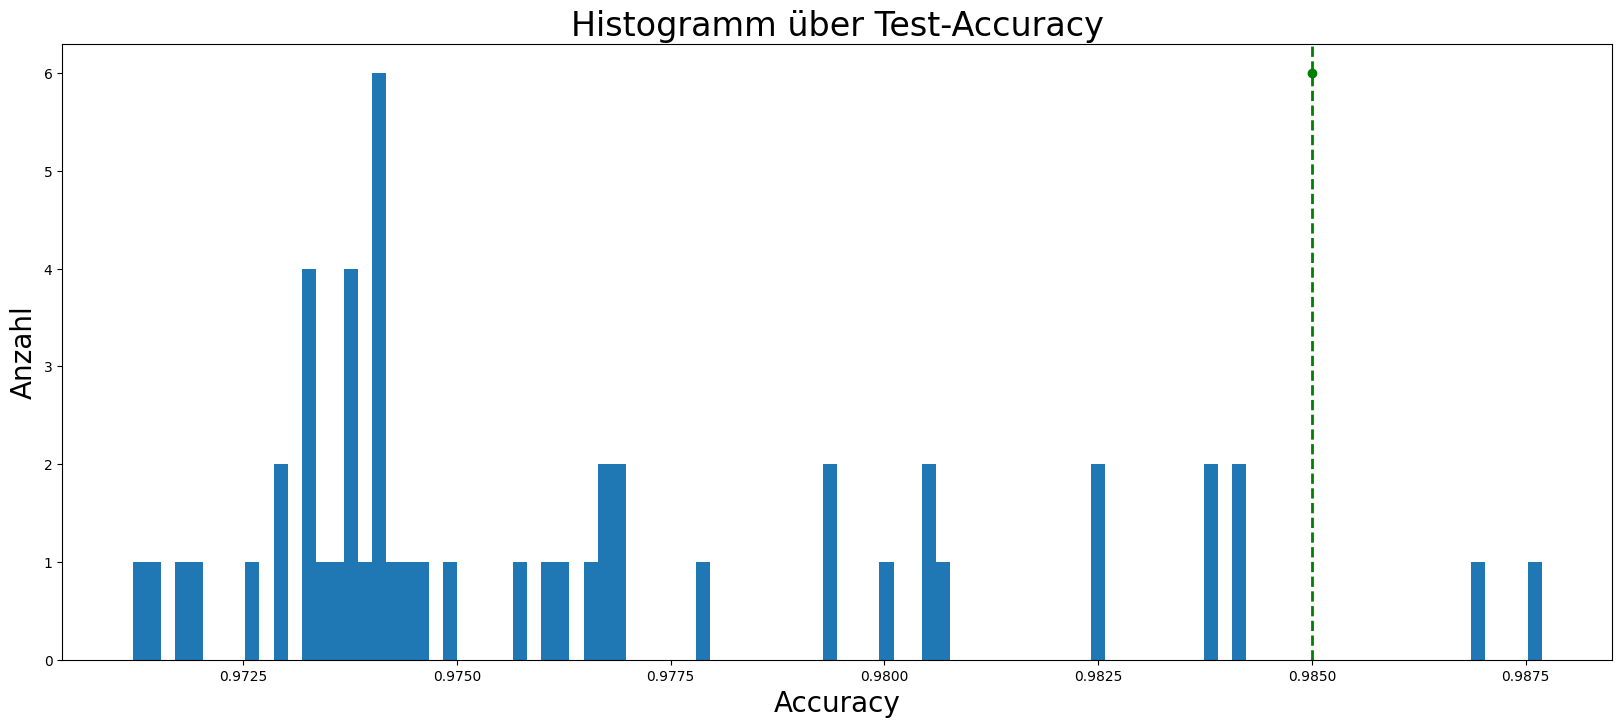

In [46]:
# Nur Histogramm:
# plt.title('Histogramm über Test-Accuracy')
# plt.ylabel("Anzahl")
# plt.xlabel("Accuracy")

# plt.hist(test_scores, bins=100);

# Histogramm mit eingezeichnetem Schwellenwert (threshold)
plt.title('Histogramm über Test-Accuracy')
plt.ylabel("Anzahl")
plt.xlabel("Accuracy")

counts, bins, patches = plt.hist(test_scores, bins=100)

threshold = 0.9850
ymax = counts.max()

plt.axvline(threshold, color="green", linestyle="--", linewidth=2)
plt.plot(threshold, ymax, marker="o", color="green")

# Schritt 4: Verdächtige Screenshots identifizieren

Verdächtige Screenshots: 49 von 51


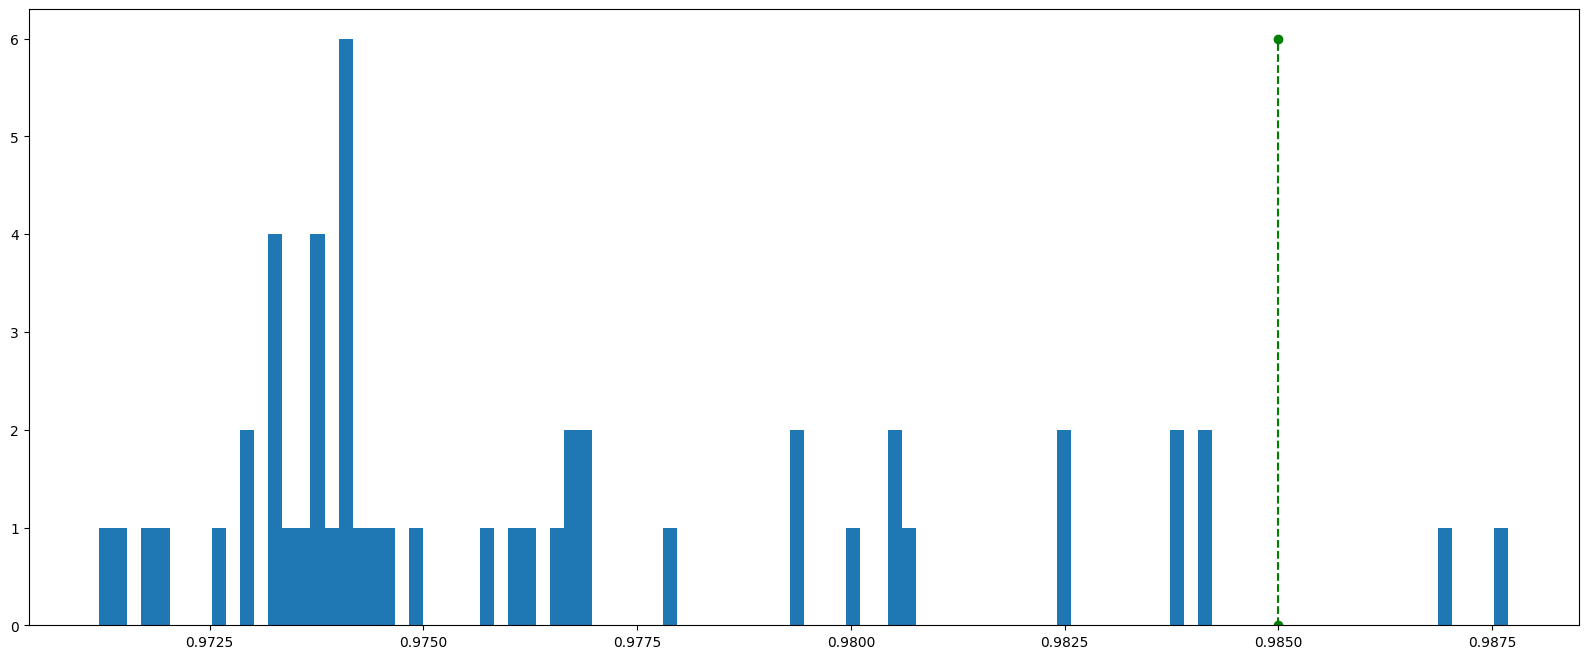

In [47]:
#@title Schwellwert: unterhalb welcher Übereinstimmung sehen wir einen Screenshot als verdächtig an? { run: "auto", display-mode: "both"  }

threshold = 0.985 #@param {type:"slider", min:0.97, max:1.0, step:0.0001}
test_mask = test_scores < threshold
n, _, _ = plt.hist(test_scores, bins=100)
plt.plot((threshold, threshold), (0, n.max()),  color='green', marker='o', linestyle='dashed');
print("Verdächtige Screenshots: {:d} von {:d}".format(np.count_nonzero(test_mask), test_mask.shape[0]));

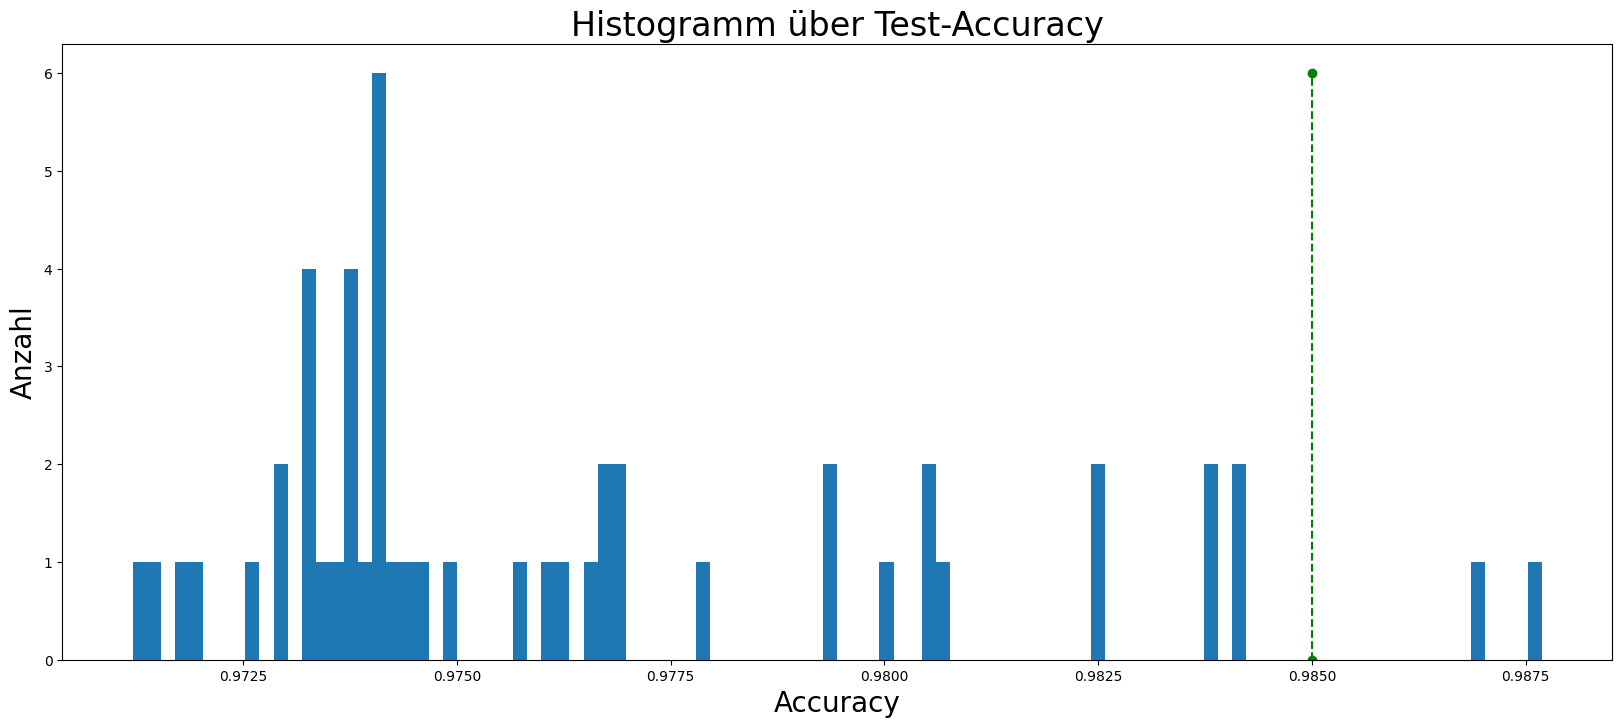

In [48]:
plt.title('Histogramm über Test-Accuracy')
plt.ylabel("Anzahl")
plt.xlabel("Accuracy")

n, _, _ = plt.hist(test_scores, bins=100)
plt.plot((threshold, threshold), (0, n.max()),  color='green', marker='o', linestyle='dashed');

## Unverdächtige Screenshots

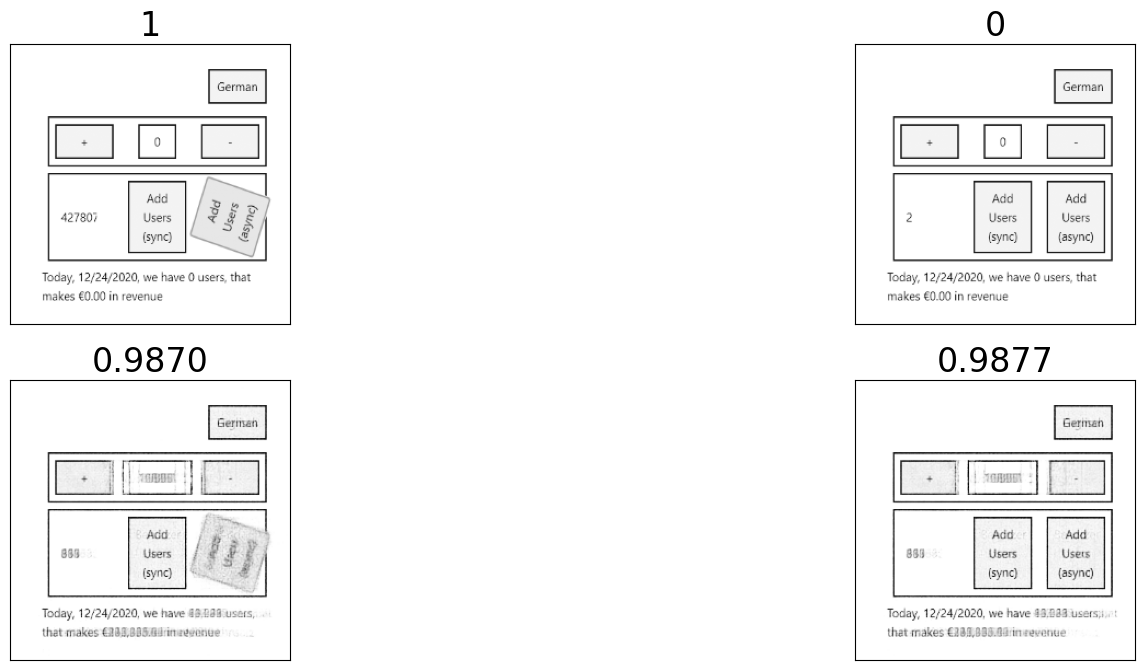

In [49]:
compare_samples(test[~test_mask], test_pred[~test_mask])

## Verdächtige Screenshots

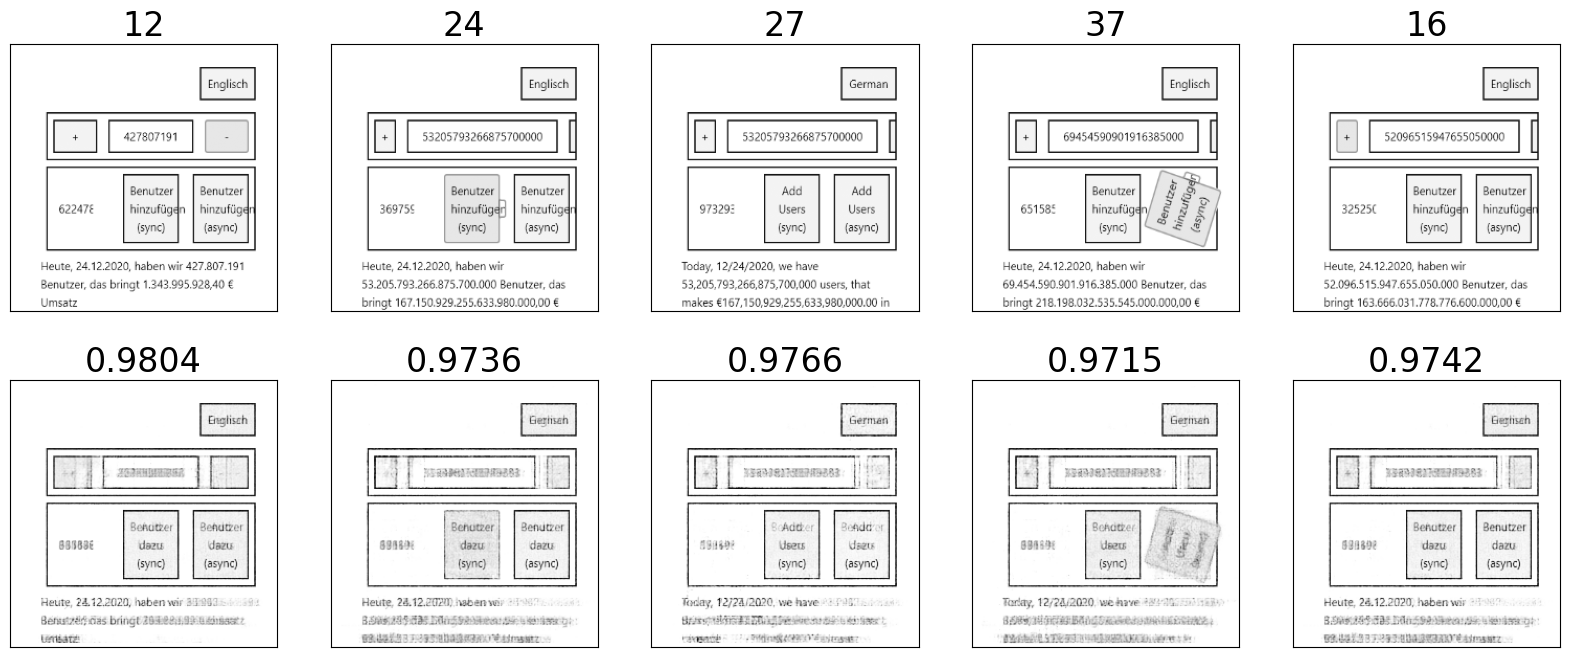

In [50]:
compare_samples(test[test_mask], test_pred[test_mask])

# Was passiert im Autoencoder?

## Interne Repräsentation

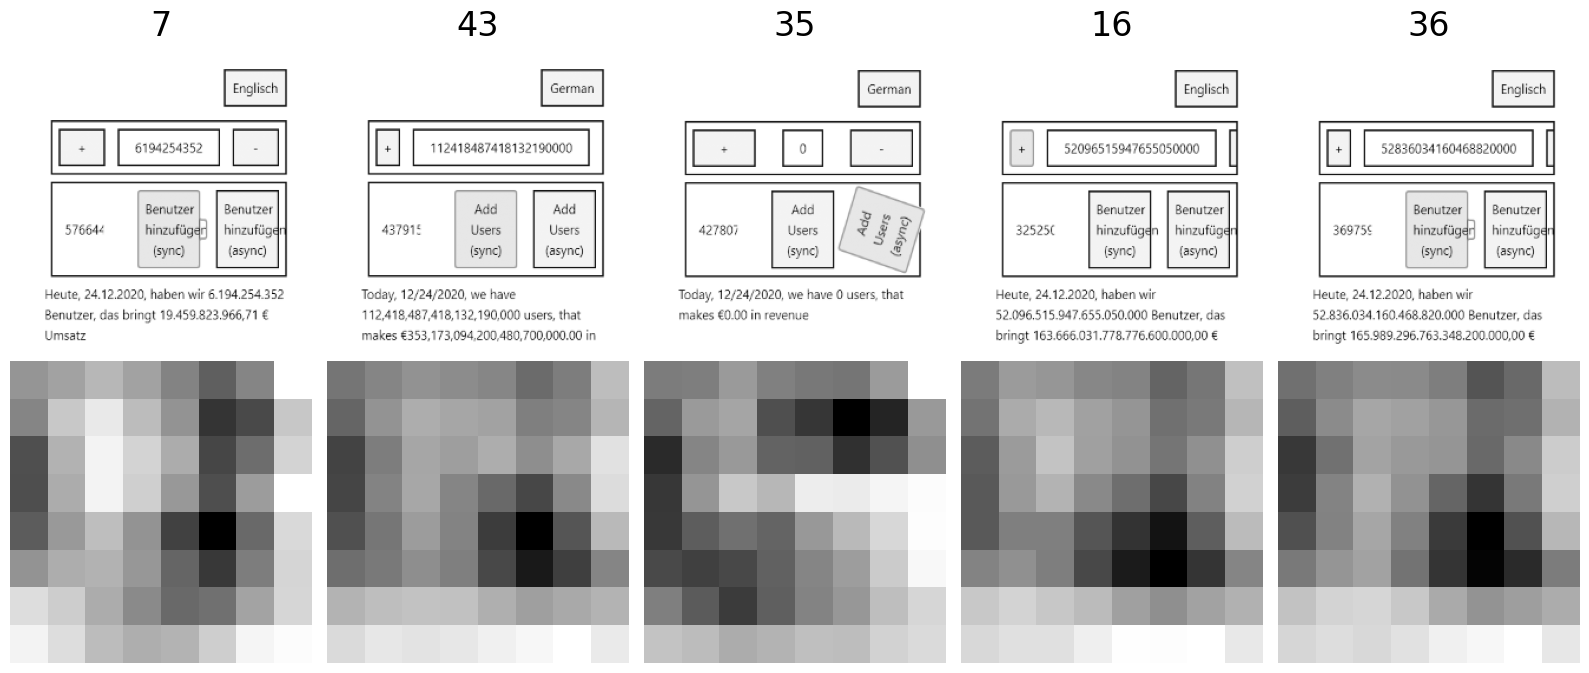

In [51]:
autoencoder.eval()

# Willkürlich ein paar Beispielbilder wählen
sample_ids    = [7, 43, 35, 16, 36]
sample_tensor = test_tensor[sample_ids].to(device)

with torch.no_grad():
    # Ausgabe direkt vor Flatten/Bottleneck: 8x8-Bild
    visual_reprs = autoencoder.encoder.features[:-1](sample_tensor)

    # normale Bottleneck-Ausgabe: 8 Werte
    bottlenecks = autoencoder.encoder(sample_tensor)

fig, axes = plt.subplots(2, len(sample_ids), figsize=(16, 7))

for i, sample_id in enumerate(sample_ids):
    axes[0, i].imshow(test[sample_id], cmap="gray")
    axes[0, i].set_title(str(sample_id), fontsize=24)
    axes[0, i].axis("off")

    axes[1, i].imshow(visual_reprs[i, 0].cpu(), cmap="gray")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

## Flaschenhals ausgeben

In [52]:
autoencoder.eval()

with torch.no_grad():
    test_embedded_imgs = (
        autoencoder.encoder(test_tensor.to(device))
        .cpu()
        .numpy()
    )

test_embedded_imgs[7]

array([161.82596  ,  51.507717 ,  12.642494 ,  -6.5085855,  14.104463 ,
        34.875336 , -91.25453  ,  23.336727 ], dtype=float32)

In [53]:
test_embedded_imgs[43]

array([124.45485  , 111.66814  , -31.358015 , -96.7485   ,  46.013294 ,
       -24.474127 , -83.184166 ,  -3.1852355], dtype=float32)